Breakdown:

potentials.py

solver.py (The main function)

Then, a fourth file, main_app.py, will bring everything together, handle the MediaPipe input, and plot the results.

 # Just an Infinite Potential Square Well


 Ultimately I want:



 - A clean, modular solver that works for **custom 1D potentials**.

 - Later: **GPU acceleration**, nicer **UI**, maybe interactive widgets.



 Technical / numerical TODO:



 - Rigorous boundary-condition (BC) enforcement(Dirichlet for infinite well)

 - Orthonormality diagnostic plots (implemented, but can be refined)

 - Convergence analysis

   - e.g. compare $N = 500$ vs $N = 2000$ to see how the discrete operator $\mathbf{D2}$ behaves

 - Analytic solution benchmarking

   - For the infinite square well: compare $E_n$ to

     $$

     E_n = \frac{\hbar^2 \pi^2 n^2}{2 m L^2}

     $$

 - Documentation + modular design


 ## 1. First-principles thinking about $V(x)$



 I want to keep an intuitive, almost classical picture of what the potential means.



 - $V(x)$ describes the **landscape of potential energy** created by the environment.

   You can think of it as a **height map** or a **hill profile**.



 - If $V(x) = 2$ (some constant), then placing a particle there means:

   - The particle "sits" at potential energy 2 (in whatever units I'm using).

   - To move around with total energy $E$, its kinetic energy is $K = E - V(x)$.

   - So if $V$ is larger, the kinetic energy available is smaller for the same $E$.



 - Intuition:

   - $V(x) = 0$ → flat ground

   - $V(x) = 2$ → you are walking on a slope of "height 2"

   - It's easier to move where $V(x)$ is low than where $V(x)$ is high.



 - If $V(x) = \infty$ in some region, then:

   - A particle would need **infinite total energy** to enter that region.

   - In quantum mechanics, this is enforced by making the wavefunction **exactly zero**

     there: the particle simply **cannot exist** in that region.



 This is exactly how the **infinite square well** is defined.

 ## 2. The infinite square well setup



 I imagine an electron (mass $m$) trapped in an infinite square well:



 - Inside the well, for $0 < x < a$:

   $$

   V(x) = 0

   $$

 - Outside the well:

   $$

   V(x) = \infty

   $$



 So the particle is strictly confined to the region $0 < x < a$.

 ### 2.1 Time-Independent Schrödinger Equation (TISE)



 The time-independent Schrödinger equation is



 $$

 H \Psi(x) = E \Psi(x)

 $$



 with the Hamiltonian



 $$

 H = -\frac{\hbar^2}{2m} \frac{d^2}{dx^2} + V(x)

 $$



 For the infinite well region (where $V(x) = 0$), the TISE reduces to:



 $$

 -\frac{\hbar^2}{2m} \frac{d^2 \Psi}{dx^2} = E \Psi

 $$

 ### 2.2 Boundary conditions and physical constraints



 We enforce some conditions on the wavefunction based on physical requirements:



 - Dirichlet boundary conditions:

   $$

   \Psi(0) = \Psi(a) = 0

   $$



   Reason (continuity argument):

   - Schrödinger's equation requires $\Psi(x)$ to be **continuous**.

   - If $\Psi(x)$ had a jump, its second derivative would involve something like a delta function,

     which would blow up the kinetic energy term.

   - Outside the well, where $V(x) = \infty$, the wavefunction must vanish:

     $$

     \Psi(0^-) = 0, \quad \Psi(a^+) = 0

     $$

   - Continuity then implies

     $$

     \Psi(0^+) = 0, \quad \Psi(a^-) = 0

     $$

     so we simply write $\Psi(0) = \Psi(a)=0$.



 - Normalization:

   $$

   \int_{-\infty}^{\infty} |\Psi(x)|^2 \, dx = 1

   $$

   In practice, for the infinite well, this is

   $$

   \int_0^a |\Psi(x)|^2 \, dx = 1.

   $$



 - Probabilistic interpretation:

   - $|\Psi(x)|^2 \, dx$ is the probability of finding the particle between $x$ and $x + dx$.

 ### 2.3 Known analytic solutions (for checking the numerics later)



 For the infinite square well, the analytic solutions are:



 - Wavefunctions:

   $$

   \Psi_n(x) = \sqrt{\frac{2}{a}} \sin\left(\frac{n \pi x}{a}\right), \quad n = 1, 2, 3, \dots

   $$



 - Energy levels:

   $$

   E_n = \frac{\hbar^2 \pi^2 n^2}{2 m a^2}

   $$



 Later in this notebook, I compare the **numerical eigenvalues** to these $E_n$ as a benchmark.

 ## 3. Discretizing the TISE



 To turn the differential equation into something a computer can solve, I:



 - Break the continuous space into small chunks.

 - Use a finite-difference approximation for derivatives.

 - Build a matrix that mimics the second derivative.

 - Solve the resulting **matrix eigenvalue problem**.



 Let me formalize that.

 ### 3.1 Discretizing the derivative



 We start from the usual definition of the derivative:



 $$

 f'(x_i) = \lim_{\Delta x \to 0} \frac{f(x_i + \Delta x) - f(x_i)}{\Delta x}

 $$



 In the code, I *do not* send $\Delta x$ to 0. Instead:



 - I choose a **fixed** grid spacing $\Delta x$.

 - I approximate the derivative using finite differences.



 For the **first derivative**, a forward-difference formula is



 $$

 f'(x_i) \approx \frac{f(x_{i+1}) - f(x_i)}{\Delta x}.

 $$



 This is called the **forward difference** operator. There are also backward and central differences,

 but for the second derivative we usually like the central difference.

 ### 3.2 Building the second derivative $f''(x_i)$



 Because $\Delta x$ is constant, and derivatives are linear, we can say:



 $$

 f''(x_i) \approx \frac{f'(x_{i+1}) - f'(x_i)}{\Delta x}.

 $$



 Now plug in the finite-difference expressions for $f'$:



 $$

 f'(x_{i+1}) \approx \frac{f(x_{i+2}) - f(x_{i+1})}{\Delta x}, \quad

 f'(x_i) \approx \frac{f(x_{i+1}) - f(x_i)}{\Delta x}

 $$



 so



 $$

 f''(x_i) \approx

 \frac{

 \frac{f(x_{i+1}) - f(x_i)}{\Delta x}

 -

 \frac{f(x_i) - f(x_{i-1})}{\Delta x}

 }

 {\Delta x}

 =

 \frac{f(x_{i+1}) - 2 f(x_i) + f(x_{i-1})}{\Delta x^2}.

 $$



 This is the standard **central difference** formula for the second derivative.



 It is exactly what I will use to approximate the operator $\frac{d^2}{dx^2}$ on a grid.

 ### 3.3 Writing the second derivative as a matrix



 Let the grid points be $x_1, x_2, x_3, x_4, \dots$ and the function values be



 $$

 f(x_i) \rightarrow

 f_i =

 \begin{bmatrix}

 f_1 \\

 f_2 \\

 f_3 \\

 f_4 \\

 \vdots

 \end{bmatrix}.

 $$



 Then the central-difference formula for the second derivative gives:



 $$

 \begin{cases}

 f''_1 = \dfrac{f_2 - 2 f_1 + f_0}{(\Delta x)^2}, \\

 f''_2 = \dfrac{f_3 - 2 f_2 + f_1}{(\Delta x)^2}, \\

 f''_3 = \dfrac{f_4 - 2 f_3 + f_2}{(\Delta x)^2}, \\

 \vdots

 \end{cases}

 $$



 The pattern is a stencil $[1, -2, 1]$ sweeping across the vector.



 In matrix form:



 $$

 \frac{d^2}{dx^2} f(x_i) \approx f''(x_i)

 = \frac{1}{(\Delta x)^2}

 \begin{bmatrix}

 -2 & 1 & 0 & 0 & \cdots \\

 1 & -2 & 1 & 0 & \cdots \\

 0 & 1 & -2 & 1 & \cdots \\

 0 & 0 & 1 & -2 & \cdots \\

 \vdots & \vdots & \vdots & \vdots & \ddots

 \end{bmatrix}

 \begin{bmatrix}

 f_1 \\

 f_2 \\

 f_3 \\

 f_4 \\

 \vdots

 \end{bmatrix}.

 $$

 ### 3.4 Schrödinger equation in matrix form



 Starting from



 $$

 -\frac{\hbar^2}{2m} \frac{d^2}{dx^2} \Psi(x) + V(x) \Psi(x) = E \Psi(x),

 $$



 when we discretize, the kinetic term becomes:



 $$

 -\frac{\hbar^2}{2m} \frac{d^2}{dx^2}

 \;\;\longrightarrow\;\;

 -\frac{\hbar^2}{2m}

 \frac{1}{(\Delta x)^2}

 \begin{bmatrix}

 -2 & 1 & 0 & 0 & \cdots \\

 1 & -2 & 1 & 0 & \cdots \\

 0 & 1 & -2 & 1 & \cdots \\

 0 & 0 & 1 & -2 & \cdots \\

 \vdots & \vdots & \vdots & \vdots & \ddots

 \end{bmatrix}.

 $$



 So the matrix version of the TISE is



 $$

 H \Psi = E \Psi

 $$



 with



 $$

 H =

 -\frac{\hbar^2}{2m}

 \frac{1}{(\Delta x)^2}

 \begin{bmatrix}

 -2 & 1 & 0 & 0 & \cdots \\

 1 & -2 & 1 & 0 & \cdots \\

 0 & 1 & -2 & 1 & \cdots \\

 0 & 0 & 1 & -2 & \cdots \\

 \vdots & \vdots & \vdots & \vdots & \ddots

 \end{bmatrix}

 + \text{diag}\big(V(x_1), V(x_2), \dots \big).

 $$



 Note:



 - This matrix acts on the **internal grid points** from $\Psi_1$ to $\Psi_{N-1}$.

 - The boundary values $\Psi_0$ and $\Psi_N$ are fixed by the **Dirichlet BC**:

   $$

   \Psi_0 = \Psi_N = 0.

   $$

 - So the computer only solves for the interior and the BC is enforced by construction.

 With this theory in place, I now build the actual code.

### psi_solve


In [1]:
# psi_solve2/ModulatedPresentation.ipynb

### constants
```python 
constants.py
```

In [2]:
L = 50
N_GRID = 2000


from functions import make_grid

x,dx,x_internal = make_grid(L,N_GRID)


### Potentials

```python 
potentials.py
```

In [3]:
from functions import inf_sqaure_well

 ### Play Ground for $V(x)$



 Here I choose which potential to use. For now, I will default to the **infinite square well**.



 - I can later uncomment and experiment with:

   - harmonic oscillator + walls,

   - double wells,

   - Gaussian wells,

   - barriers inside wells, etc.

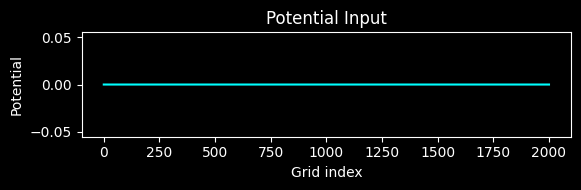

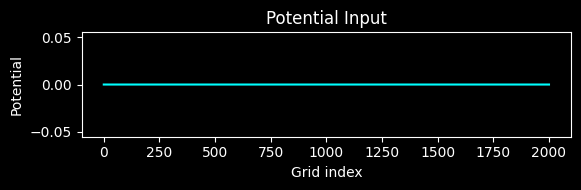

In [4]:
import numpy as np
def custom2(value):
    return value * np.ones_like(x)

V = inf_sqaure_well(x,-L/2,L/2)


# --- 3. USER PLAYGROUND (Mix and Match Here) ---

# EXAMPLE 1: Half-Harmonic Oscillator (Wall on left, parabola on right)
# V = inf_wall(x, 'left', 2) + harmonic(x, center=5, k=5)

# EXAMPLE 2: A Harmonic Oscillator with a Barrier in the middle
#V = harmonic(x, k=5) + finite_barrier(x, center=L/2, width=0.5, height=50)

# EXAMPLE 3: Double Well (Two Gaussians)
# V = gaussian_well(x, center=3) + gaussian_well(x, center=7)

# Let's run Example 1:
#V = inf_wall(x, 'left', 2) + harmonic(x, center=5, k=5)

from functions import plot_V

plot_V(V)

 For an $N \times N$ matrix (e.g. $4 \times 4$ toy example), the pattern is:



 $$

 \begin{bmatrix}

 1 & 1 & 0 & 0  \\

 1 & 2 & 2 & 0  \\

 0 & 2 & 3 & 3  \\

 0 & 0 & 3 & 4  \\

 \end{bmatrix}

 $$



 - Main diagonal: $N$ elements

 - Off diagonals: each has $N-1$ elements



 Here, my actual matrix is the finite-difference approximation to $\dfrac{d^2}{dx^2}$,

 and I then build the Hamiltonian:



 $$

 - \frac{\hbar^2}{2m} \left( \frac{d^2}{dx^2} \right) \Psi = E \Psi

 $$



 turns into



 $$

 H \Psi = E \Psi,

 $$



 where $H$ is built from $D2$ plus the potential.

In [5]:
hbar = 1
m = 1

from functions import kinetic_operator
T = kinetic_operator(N_GRID, dx, hbar=hbar,m=m)


### Solve

``` python 
solver.py 
```

 The integral



 $$

 \int_{x_1}^{x_N} f(x)\,dx \approx \sum_{i=1}^{N} f(x_i)\,\Delta x

 $$



 is implemented as a Riemann sum on the grid.

In [6]:
from functions import solve
E, psi = solve(T, V, dx)
 


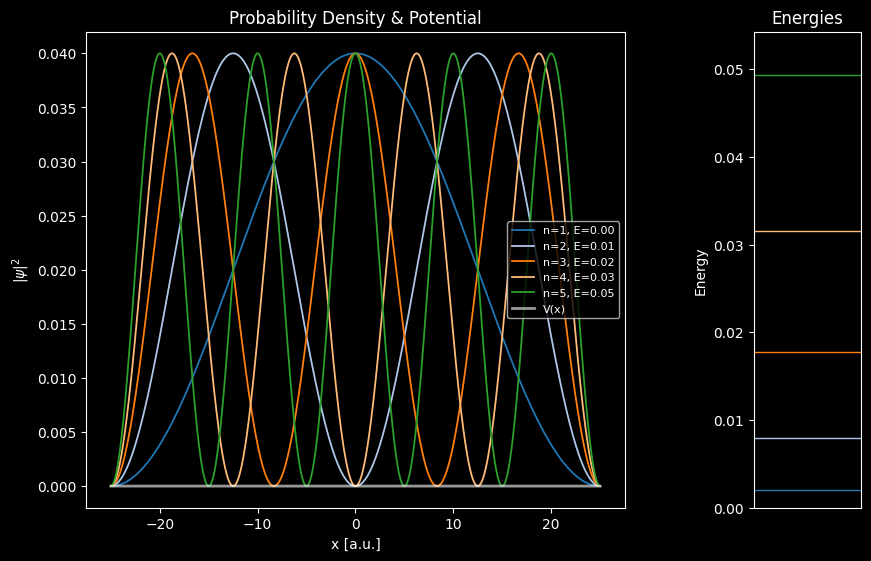

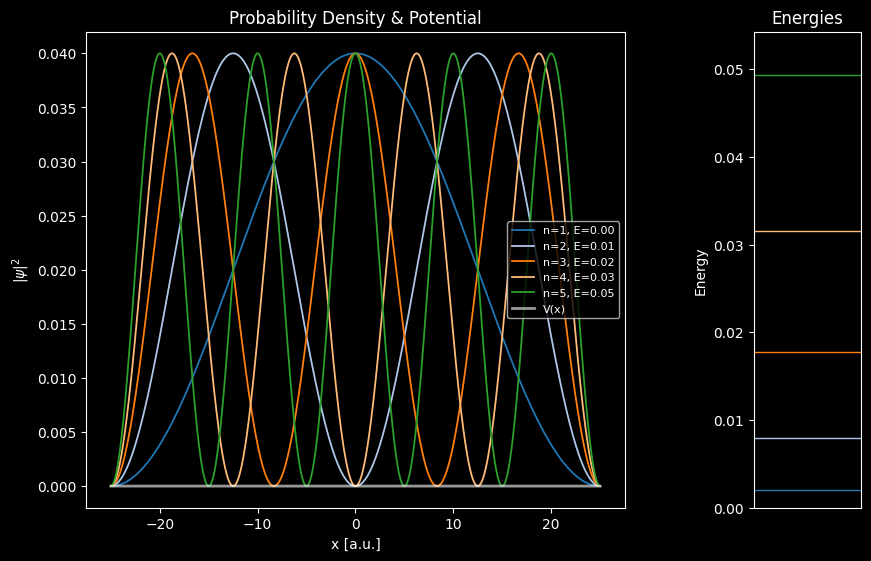

In [7]:
from functions import plot_alive
plot_alive(E, psi, V, x, nos=5)


In [8]:
# Debug 2
bool(0)
print(E)
E.shape
E[-1]

[1.97392047e-03 7.89567703e-03 1.77652551e-02 ... 3.20318303e+03
 3.20319290e+03 3.20319883e+03]


3203.198826079482

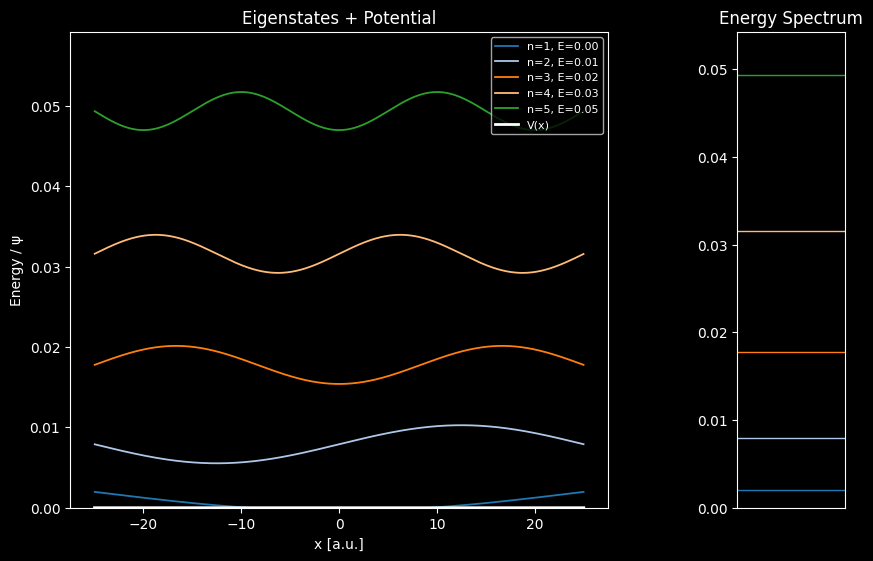

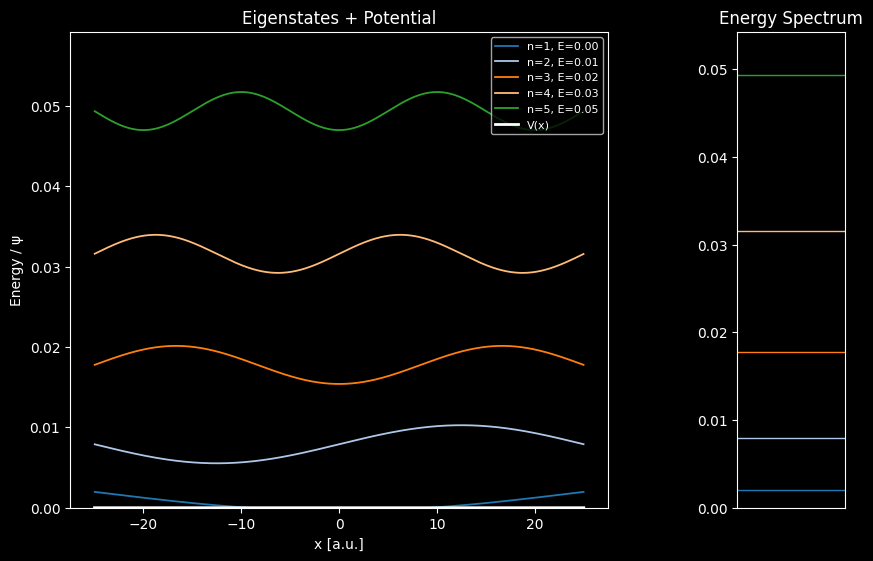

In [9]:
#%matplotlib widget
# Inaccurate Plot for intution (Like the Textbook)

from functions import plot_dead

plot_dead(E, psi, V, x, nos=5)

 ## 4. How do I trust the computer?



 So far:



 - I constructed a Hamiltonian matrix.

 - I asked the computer for its eigenvalues and eigenvectors.

 - I enforced boundary conditions by construction.



 But how do I know these eigenvectors are actually good **approximations to true eigenstates**?



 Two big checks:



 1. **Orthonormality** (linear algebra + normalization)

 2. **Analytic benchmarking** (compare to known formulas)



 ### 4.1 Orthonormality



 If I have two different eigenstates, $\psi_m$ and $\psi_n$ (with $m \neq n$), their inner product must be zero:



 $$

 \langle \psi_m | \psi_n \rangle = 0.

 $$



 This is called **orthogonality**.

 If $m = n$, then the inner product is 1 (if I normalize them properly):



 $$

 \langle \psi_n | \psi_n \rangle = 1.

 $$



 So the **overlap matrix** or **orthonormality matrix** is:



 $$

 \mathbf{S}_{mn} = \langle \psi_m | \psi_n \rangle

 = \int \psi_m^*(x) \psi_n(x) \, dx

 $$



 and in discrete form on the grid:



 $$

 \mathbf{S}_{mn} \approx \sum_i \psi_m(x_i) \psi_n(x_i) \, \Delta x.

 $$



 For properly normalized eigenstates of a Hermitian Hamiltonian, $\mathbf{S}$ should be **the identity matrix**:

 - Diagonal = 1

 - Off-diagonal = 0 (up to small numerical errors)

In [10]:
from functions import check_ortho,show_matrix

overlap_matrix = check_ortho(psi,dx)



show_matrix(overlap_matrix,how="normal")




--- Orthonormality Check (First 20 states) ---
Overlap Matrix should approximate the Identity Matrix:
[[ 1.00000000e+00 -8.87734552e-17  6.65800914e-17  1.77546910e-16
  -3.32900457e-16  2.21933638e-17  9.98701371e-17 -2.33030320e-16
  -2.44127002e-16  2.21933638e-17 -1.16515160e-16  1.33160183e-16
   8.32251143e-17  1.10966819e-17 -1.44256865e-16 -1.05418478e-16
  -1.02644308e-16 -1.05418478e-16  1.10966819e-16  4.99350686e-17]
 [-8.87734552e-17  1.00000000e+00  2.21933638e-16  3.10707093e-16
   3.32900457e-16 -1.10966819e-16  0.00000000e+00  5.43737413e-16
  -6.65800914e-17  1.80321081e-16 -3.32900457e-17  2.21933638e-17
   3.88383867e-17  8.87734552e-17  2.21933638e-17 -3.88383867e-17
   9.98701371e-17 -2.91287900e-17  7.21284324e-17  6.10317505e-17]
 [ 6.65800914e-17  2.21933638e-16  1.00000000e+00  2.66320366e-16
  -7.98961097e-16 -5.54834095e-16  8.76637871e-16 -4.43867276e-16
  -6.99090960e-16 -1.55353547e-16 -3.13481264e-16  6.65800914e-17
   1.66450229e-16  3.88383867e-17 -2.

In [11]:

show_matrix(overlap_matrix,how="round",round_value=10)


[[ 1. -0.  0.  0. -0.  0.  0. -0. -0.  0. -0.  0.  0.  0. -0. -0. -0. -0.
   0.  0.]
 [-0.  1.  0.  0.  0. -0.  0.  0. -0.  0. -0.  0.  0.  0.  0. -0.  0. -0.
   0.  0.]
 [ 0.  0.  1.  0. -0. -0.  0. -0. -0. -0. -0.  0.  0.  0. -0. -0. -0.  0.
   0.  0.]
 [ 0.  0.  0.  1. -0. -0. -0. -0. -0.  0. -0.  0.  0.  0. -0. -0. -0.  0.
   0.  0.]
 [-0.  0. -0. -0.  1. -0. -0. -0.  0. -0. -0. -0.  0. -0.  0.  0.  0. -0.
  -0. -0.]
 [ 0. -0. -0. -0. -0.  1.  0.  0. -0.  0. -0.  0.  0.  0. -0.  0.  0.  0.
   0.  0.]
 [ 0.  0.  0. -0. -0.  0.  1. -0. -0.  0. -0.  0.  0.  0. -0.  0. -0.  0.
   0.  0.]
 [-0.  0. -0. -0. -0.  0. -0.  1.  0. -0. -0. -0.  0. -0. -0. -0. -0. -0.
   0. -0.]
 [-0. -0. -0. -0.  0. -0. -0.  0.  1. -0. -0.  0.  0.  0. -0. -0. -0.  0.
   0.  0.]
 [ 0.  0. -0.  0. -0.  0.  0. -0. -0.  1.  0. -0. -0. -0.  0.  0.  0. -0.
  -0. -0.]
 [-0. -0. -0. -0. -0. -0. -0. -0. -0.  0.  1.  0.  0.  0.  0.  0.  0.  0.
  -0. -0.]
 [ 0.  0.  0.  0. -0.  0.  0. -0.  0. -0.  0.  1.  0.  0. -0. -0.

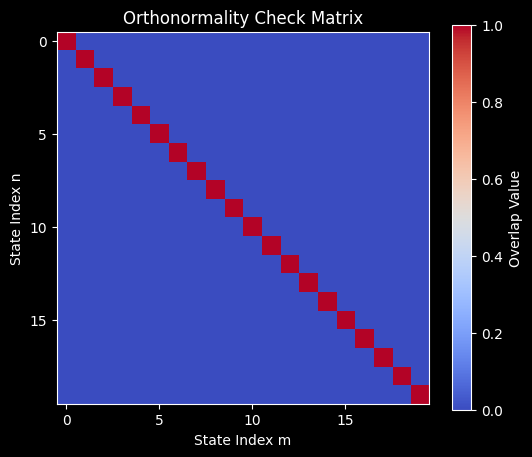

In [12]:
show_matrix(overlap_matrix,how="plot",round_value=10)


 ## 5. Analytical tests (benchmarking)



 Orthonormality tells me the eigenvectors make sense **as a basis**, but I still want to know:



 > Are these the *correct* eigenstates for **this** potential?



 For that, I compare:



 - The **numerical** energy levels from the matrix diagonalization.

 - The **analytic** formulas I already know:

   - Infinite square well energy spectrum.

   - (Optionally) harmonic oscillator spectrum when I switch potential.



 ---



 ### 5.1 Indexing remark



 - In physics, the ground state is $E(n = 1)$ for the infinite square well.

 - In Python, array indices start at 0.



 So:



 - Physically: $n = 1, 2, 3, \dots$

 - In code: `i = 0, 1, 2, ...` corresponds to $n = i + 1$.



 This mismatch is annoying but standard in programming.

 ### 5.2 Infinite square well energies



 The analytic formula:



 $$

 E_{n}^{\text{analytic}} = \frac{\hbar^2 \pi^2 n^2}{2 m L^2}

 $$



 (Here $L$ is the well width.)

In [13]:
from functions import check_ISW_analytic
check_ISW_analytic(E,L,hbar=1.0, m=1.0, max_levels=6)


### ENERGY BENCHMARK: Infinite Square Well ###
-------------------------------------------------------
| n | Analytic E | Numerical E | % Error |
-------------------------------------------------------
| 1 | 0.001974   | 0.001974    | 0.0000 % |
| 2 | 0.007896   | 0.007896    | 0.0001 % |
| 3 | 0.017765   | 0.017765    | 0.0002 % |
| 4 | 0.031583   | 0.031583    | 0.0003 % |
| 5 | 0.049348   | 0.049348    | 0.0005 % |
| 6 | 0.071061   | 0.071061    | 0.0007 % |
-------------------------------------------------------


## Convergence Test



In [14]:
# COnvergence Test

 ### 5.3 Harmonic oscillator benchmark



 When I switch $V(x)$ to a harmonic oscillator $V(x) = \tfrac{1}{2} k (x-x_0)^2$ and run the solver:



 - The analytic energy levels are

   $$

   E_n^{\text{HO}} = \left(n + \frac{1}{2}\right) \hbar \omega

   $$

   where $\omega = \sqrt{k/m}$ and $n = 0, 1, 2, \dots$.



 - I can compare the numerical $E_n$ to those values.

 - This is a good **second** test after the infinite square well.

In [15]:
# Assuming Last_k_value, hbar, m, E, and CHECK_N are available
from functions import check_harmonic_analytic
check_harmonic_analytic(E,max_levels=6)

I don't think this is a Harmonic Oscillator, or an error occurred: name 'Last_k_value' is not defined


In [16]:

import cv2
import mediapipe as mp
# Initialize Grid
# CORRECT CODE
x_full, dx, x_solver = make_grid(L=L, N=N_GRID)

# Build Kinetic Energy Matrix
T = kinetic_operator(N_GRID, dx, hbar=hbar,m=m)

print("Physics Engine Ready.")
print(f"Grid: {N_GRID} points over L={L}")

Physics Engine Ready.
Grid: 2000 points over L=50


In [17]:
## 🚀 Webcam Setup and Capture (Jupyter/Colab)

# 1. Imports (Make sure these are available in your environment)
import cv2
import numpy as np
import time
import math
import mediapipe as mp 
from IPython.display import display, Image, clear_output
from scipy.interpolate import interp1d # Needed for later potential resizing

# 2. MediaPipe Initialization (REQUIRED IN NOTEBOOK)
mp_hands = mp.solutions.hands
hands = mp_hands.Hands(max_num_hands=2, min_detection_confidence=0.7)
drawer = mp.solutions.drawing_utils

from functions import display_params

# Create a notebook-friendly version of the function
def capture_potential_notebook(tune, A_MIN, A_MAX, mode='wait'):
    
    # Copy relevant constants from the file for local scope
    THUMB_TIP_ID = 4
    INDEX_TIP_ID = 8
    REQUIRED_STABLE_FRAMES = 45
    MOVEMENT_THRESHOLD = 0.015
    PLOT_CEILING_A = 10.0
    EPS = 1e-9
    
    D_MIN = 0.001
    D_MAX = 0.2
    D_RANGE = D_MAX - D_MIN
    A_RANGE = A_MAX - A_MIN
    SLOPE = -A_RANGE / D_RANGE
    INTERCEPT = A_MAX - SLOPE * D_MIN
    # End of copied constants
    
    cap = cv2.VideoCapture(0)
    captured_V = None
    
    if not cap.isOpened():
        print("Error: Could not open video stream. Check permissions or camera index.")
        return None

    stability_counter = 0
    prev_landmarks = []
    
    start_time = time.time()
    MAX_RUN_TIME_SECONDS = 30 
    
    print("Controls: HOLD STILL to capture, or wait for the time limit to exit.")

    while True:
        ret, frame = cap.read()
        if not ret:
            break
            
        frame = cv2.flip(frame, 1)
        h, w, _ = frame.shape
        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        res = hands.process(rgb)

        pot_profile = None
        mode_msg = "No Hands"
        params_to_display = []
        current_landmarks_flat = []

        # --- LANDMARK AND POTENTIAL LOGIC (Skipped for brevity, assume this is correct) ---
        if res.multi_hand_landmarks:
            for hand_lms in res.multi_hand_landmarks:
                for lm in hand_lms.landmark:
                    current_landmarks_flat.extend([lm.x, lm.y])
            for lm in res.multi_hand_landmarks:
                drawer.draw_landmarks(frame, lm, mp_hands.HAND_CONNECTIONS)
            
            # TWO HANDS (Square Well)
            if len(res.multi_hand_landmarks) >= 2:
                mode_msg = "Mode: Square Well (Auto-Centered)"
                x_coords = [lm.landmark[INDEX_TIP_ID].x * w for lm in res.multi_hand_landmarks]
                x_coords.sort()
                xL_hand, xR_hand = int(x_coords[0]), int(x_coords[1])
                cv2.line(frame, (xL_hand, 0), (xL_hand, h), (0, 255, 255), 2)
                cv2.line(frame, (xR_hand, 0), (xR_hand, h), (0, 255, 255), 2)
                well_width = xR_hand - xL_hand
                center_screen = w / 2
                centered_L = center_screen - (well_width / 2)
                centered_R = center_screen + (well_width / 2)
                params_to_display.append(f"Width: {well_width:4.0f} px")
                params_to_display.append(f"Status: Centered")
                x_space = np.linspace(0, w, 400)
                pot_profile = np.ones_like(x_space)
                pot_profile[(x_space > centered_L) & (x_space < centered_R)] = 0
            # ONE HAND (QHO)
            elif len(res.multi_hand_landmarks) == 1:
                mode_msg = "Mode: Pinch QHO"
                lm = res.multi_hand_landmarks[0]
                thumb = lm.landmark[THUMB_TIP_ID]
                index = lm.landmark[INDEX_TIP_ID]
                dx = index.x - thumb.x
                dy = index.y - thumb.y
                pinch_distance = math.sqrt(dx**2 + dy**2)
                A = SLOPE * pinch_distance + INTERCEPT
                A = max(A_MIN, min(A_MAX, A))
                x_space = np.linspace(-1, 1, 400)
                pot_profile = A * (x_space**2)
                pot_profile = pot_profile / (PLOT_CEILING_A + EPS)
                pot_profile = np.clip(pot_profile, 0.0, 1.0)
                params_to_display.append(f"Pinch Dist: {pinch_distance:.4f}")
                params_to_display.append(f"A (curv): {A:.4f}")
                display_pts = np.column_stack(((x_space + 1)/2 * w, (1 - pot_profile) * h)).astype(np.int32)
                cv2.polylines(frame, [display_pts], False, (0, 0, 255), 2)
        # --- END LANDMARK AND POTENTIAL LOGIC ---

        # STABILITY CHECK
        if mode != 'wait':
            if current_landmarks_flat and prev_landmarks and len(current_landmarks_flat) == len(prev_landmarks):
                movement = np.mean(np.abs(np.array(current_landmarks_flat) - np.array(prev_landmarks)))
                stability_counter = stability_counter + 1 if movement < MOVEMENT_THRESHOLD else 0
            else:
                stability_counter = 0

            prev_landmarks = current_landmarks_flat

            if stability_counter > 0:
                progress = stability_counter / REQUIRED_STABLE_FRAMES
                bar_width = int(w * progress)
                color = (0, 255*progress, 255*(1-progress))
                cv2.rectangle(frame, (0, 0), (bar_width, 20), color, -1)
                cv2.putText(frame, "HOLDING...", (10, 15), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 1)

            # Finished
            if stability_counter >= REQUIRED_STABLE_FRAMES and pot_profile is not None:
                captured_V = pot_profile
                cap.release()
                # --- LINE REMOVED HERE (was cv2.destroyAllWindows()) ---
                print("Stable capture triggered and video stream closed.")
                return captured_V

        # UI OVERLAY
        cv2.putText(frame, mode_msg, (10, 50), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
        display_params(frame, params_to_display)
        
        # NOTEBOOK DISPLAY
        clear_output(wait=True) 
        _, buffer = cv2.imencode('.jpeg', frame)
        display(Image(data=buffer.tobytes()))
        
        time.sleep(0.01)

        if time.time() - start_time > MAX_RUN_TIME_SECONDS:
            print(f"Time limit of {MAX_RUN_TIME_SECONDS} seconds reached.")
            break

    # -----------------------------------------------------------------
    cap.release()
    # cv2.destroyAllWindows() <--- REMOVE THIS LINE TOO
    return captured_V


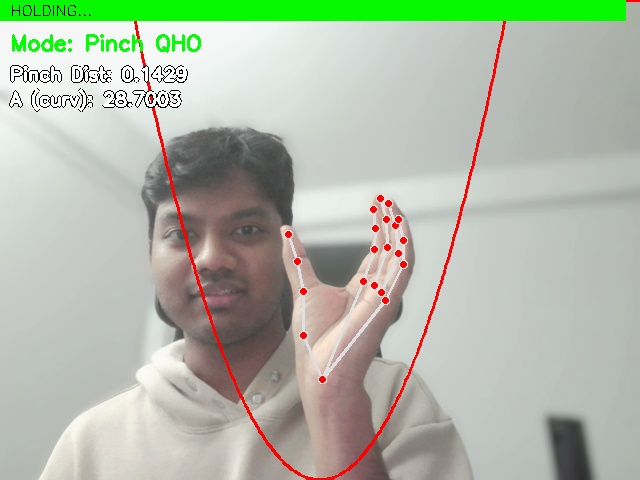

Stable capture triggered and video stream closed.
Potential capture successful.
Solver complete. Found 2000 eigenstates.


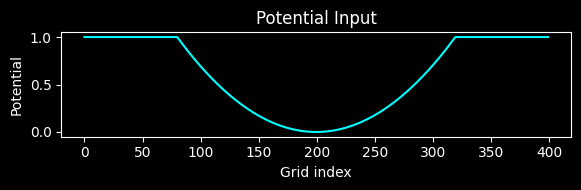

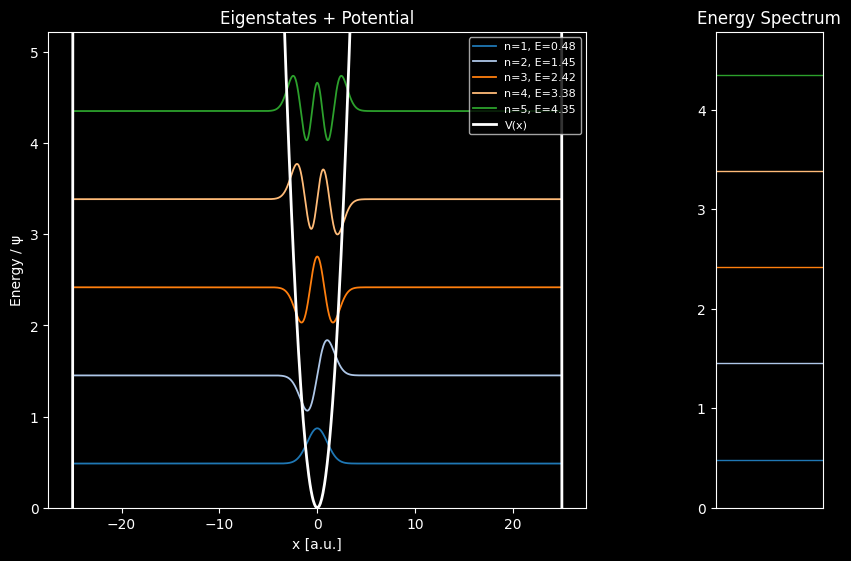

In [20]:

# Call the new notebook function
V_raw_input = capture_potential_notebook(mode='captuare', tune=1, A_MIN=0, A_MAX=100) 
plot_V(V_raw_input)
# ... (Paste the corrected capture_potential_notebook function here) ...
# ... (Paste the display_params function here) ...

# 4. Execute Capture
print("Starting camera stream...")
# Assuming A_MIN and A_MAX are defined or hardcoded.
A_MIN = 0
A_MAX = 100 
V_raw_input = capture_potential_notebook(mode='capture', tune=1, A_MIN=A_MIN, A_MAX=A_MAX) 

if V_raw_input is not None:
    # Use the imported plot_V from your file or define it here
    # plot_V(V_raw_input) 
    print("Potential capture successful.")
else:
    print("Potential capture failed or was aborted.")


if V_raw_input is None:
    print("Error: Run the Camera Input cell first to get V_raw_input!")
else:
    # --- 1. Map Input to Physics Grid (Interpolation & Scaling) ---
    
    # 1.1 Define the internal grid points for the solver
    x_solver = x[1:-1] # Interior points for V_final (length N)
    
    # 1.2 Interpolation: Map the camera's resolution to the solver's grid
    V_interpolated = np.interp(
        x_solver, 
        np.linspace(-L/2, L/2, len(V_raw_input)), # Input X-space
        V_raw_input                               # Input V-values
    )

    # 1.3 Scaling: Convert dimensionless input to energy units
    V_max_height = 100.0 # Heuristic scaling factor
    V_internal = V_interpolated * V_max_height
    
    # 1.4 Prepare V_full (The potential array including the walls, length N+2)
    # The V_full is required by your current 'solve' function signature 
    # to maintain consistency with the inf_sqaure_well definition.
    # We pad the V_internal array with 0s for the walls, knowing that 
    # the Hamiltonian construction will use V_internal (V_full[1:-1]) only.
    V_full = np.pad(V_internal, (1, 1), 'constant', constant_values=0.0)


    # --- 2. Solve H psi = E psi using defined function ---
    # The 'solve' function handles the Hamiltonian construction (T + diag(V)) 
    # and normalization internally.
    try:
        E_vals, psi_vecs = solve(T, V_full, dx)
        print(f"Solver complete. Found {E_vals.size} eigenstates.")
    
    except Exception as e:
        print(f"Error during solve: {e}")
        # Check if the potential is too high, causing numerical instability
        if np.max(V_internal) > 1e9:
             print("Potential may be too steep or high, leading to numerical error.")
        exit()


    # --- 3. Visualization using defined function (or adapted visualization) ---
    
    # The original 'plot_dead' function uses default constants (nos=5).
    # We call it here, passing the calculated results:
    
    # Note: We pass V_full to plot_dead, as it contains the boundary info
    # that your V_clipped logic uses for plotting the potential shape.
    plot_dead(E=E_vals, psi=psi_vecs, V=V_full, x=x, nos=5)
